# Manuscript Fig 2 - Frontal composite + standard error 

## 1 — Setup

In [1]:
# startup file defines np, xr, pd, plt, names, font_for_print, etc.
import os, sys
STARTUP_2026_coldfronts_mhws = "./2026_coldfronts_mhws_startup.py"
exec(open(STARTUP_2026_coldfronts_mhws).read())

## 2 — Load data

Same files as `frontal_passage_composites.ipynb` & `stats.ipynb`. Only the full-record frontal
metrics are needed, no seasonal partitioning here 

In [2]:
# region names defined in startup file
print(names)

# Load the serialized products generated by data_prep_manuscript.py.
# The repository's pickle_load helper is used because these .npy files contain
# pickle-serialized Python objects rather than NumPy arrays.

interm_loc_6hr = pickle_load("interm_loc_6hr_oisst", "../data/")
mhw_loc_6hr = pickle_load("mhw_loc_6hr_oisst", "../data/")
front_metrics_full = pickle_load("front_metrics_era5_full", "../data/")
front_catalog = pickle_load("front_catalog", "../data/")
front_strength_loc= xr.open_dataset('../data/coldfront_strength_loc.nc')
front_strength = {name: front_strength_loc['F_strength'].sel(loc=name) for name in names}


# anomaly retaining the seasonal cycle, in case you want var='tempa_seas'
for name in names:
    ts = interm_loc_6hr[name]['ts']
    interm_loc_6hr[name]['tempa_seas'] = ts - float(ts.mean())

['JordanBasin', 'ScotianShelf1', 'ScotianShelf2', 'Pioneer', 'SlopeN', 'SlopeS', 'MAB_North', 'MAB_south']
load from:  ../data/interm_loc_6hr_oisst.npy
load from:  ../data/mhw_loc_6hr_oisst.npy
load from:  ../data/front_metrics_era5_full.npy
load from:  ../data/front_catalog.npy


### subsample front based on fstrength quantiles if desired - IF NOT skip to next cell

In [ ]:
# Frontal strength sampled at each frontal passage for every selected region
fstrength = {}
for region in names:
    front_times = front_metrics_full[region]['time_start']
    fstrength[region] = [
        front_strength[region].sel(time=t, method='nearest').values
        for t in front_times
    ]

# Frontal-strength quartiles for each region
fstrength_quantiles = {
    region: xr.DataArray(fstrength[region]).quantile([0.25, 0.50, 0.75], skipna=True)
    for region in names
}
fstrength_quantiles




# add to dictionary
for region in names:
    front_metrics_full[region]['front_strength'] = fstrength[region]
    front_metrics_full[region]['front_strength_quantiles'] = fstrength_quantiles[region]
# Keep frontal passages at or above the selected strength percentile
PERCENTILE = 0.75
front_metrics_full_subsampled = {}

for region in REGIONS:
    strength_values = np.asarray(fstrength[region], dtype=float)
    strength_threshold = float(
        fstrength_quantiles[region].sel(quantile=PERCENTILE).item()
    )
    strength_mask = np.isfinite(strength_values) & (strength_values >= strength_threshold)

    region_metrics = front_metrics_full[region]
    front_metrics_full_subsampled[region] = {
        key: np.asarray(values)[strength_mask]
        if np.ndim(values) > 0 and len(values) == strength_mask.size
        else values
        for key, values in region_metrics.items()
    }
    print(
        f"{REGION_LABELS.get(region, region)}: "
        f"{int(strength_mask.sum())}/{strength_mask.size} frontal passages "
        f"with strength >= {strength_threshold:.3f}"
    )

# Use the filtered front metrics in the composite calculations below.
front_metrics_full = front_metrics_full_subsampled

## 3 - Prep variables

These settings define the inputs and comparisons for the composite analysis:

- **Regions and temperature**
  - `REGIONS` selects the regions shown in the figure.
  - `VAR` chooses the temperature variable to composite.
  - `METHOD` sets how each event time series is normalized.
- **MHW classification**
  - `COLLOCATION` defines when a frontal passage is considered coincident with an MHW.
  - `DX_TIMESTEPS` separates short and long MHW events; 40 six-hourly steps correspond to 10 days.
- **Event timing and temperature change**
  - `TIME` sets the 6-hourly window from 5 days before to 5 days after each passage.
  - `DELTA_LAGS` sets the two relative times used to calculate temperature change and its standard error.
- **Figure styling**
  - `STATES`, `STATE_COLORS`, `STATE_STYLES`, and `STATE_LABELS` keep the MHW groups visually consistent.
  - `FS` controls figure font sizes.

In [16]:
# regions for the rows, in plotting order
REGIONS = ['JordanBasin', 'Pioneer', 'MAB_North']
REGION_LABELS = {
    'JordanBasin': 'Jordan Basin',
    'Pioneer':     'Pioneer',
    'MAB_North':   'MAB North',
}
assert all(r in names for r in REGIONS), [r for r in REGIONS if r not in names]

# composite settings
VAR        = 'tempa'            # 'tempa' or 'tempa_seas'
METHOD     = 'event_centered'   # 'absolute' | 'event_centered' | 'pre_event'
COLLOCATION = 'frontal'         # MHW present in the 24 h prior to passage

# short/long threshold. extract_front_mhw_windows compares against mhw 'duration'
# which is in TIMESTEPS, so 40 timesteps = 10 days (matches the 10-day cut in stats.ipynb)
DX_TIMESTEPS = 40
DX_DAYS      = DX_TIMESTEPS / 4

# relative time axis: -5 d to +5 d at 6-hourly resolution, 41 steps
TIME = np.arange(-5*24, (5*24)+6, 6)

# delta_t = T(post lag) - T(pre lag), two fixed times relative to frontal passage.
# both must land on the 6-hourly TIME grid. (-120, 120) reproduces the stats.ipynb
# endpoint definition, T(+5 d) - T(-5 d).
DELTA_LAGS = (-24, 36)   # 1 day before passage, 1.5 days after
# DELTA_LAGS = (-72, 72)   # 1 day before passage, 1.5 days after
# DELTA_LAGS = (-96, 96)   # 1 day before passage, 1.5 days after


# one palette shared by both columns so line i and marker i are visually tied.
# colors taken from the stats.ipynb errorbar figure.
STATES = ['No MHW', 'Short', 'Long']
STATE_COLORS = {'No MHW': '#4C72B0', 'Short': '#DD8452', 'Long': '#C44E52'}
STATE_STYLES = {'No MHW': '-',       'Short': '-',       'Long': '-'}
STATE_LABELS = {
    'No MHW': 'No MHW',
    'Short':  f'Short (<{DX_DAYS:.0f}d)',
    'Long':   f'Long (≥{DX_DAYS:.0f}d)',
}

# font sizes, applied after font_for_print()
FS = {'tick': 8, 'label': 9, 'title': 9, 'legend': 8, 'annot': 7}

VAR_YLABELS = {
    'tempa':      'Norm. temp. anom. [\N{DEGREE SIGN}C]',
    'tempa_seas': 'Norm. temp. anom. w/ seas. cycle [\N{DEGREE SIGN}C]',
    'ts':         'Norm. SST [\N{DEGREE SIGN}C]',
}

## 4 — Functions to Build Composites

This function extracts a centered 10-day temperature window for each frontal passage, checks for MHWs within the selected collocation window, and classifies passages as MHW-coincident or no-MHW. It can also separate coincident events into short- and long-duration MHW groups.

In [7]:
# ---------------------------------------------------------
# Extract frontal event windows and determine MHW coincidence
# ---------------------------------------------------------
def extract_front_mhw_windows(name, dummy_front, collocation='frontal', mhw_special='', dx=40, var='tempa'):
    """
    Extract ±5 day windows around each frontal event and classify
    which events coincide with an MHW.

    Parameters
    ----------
    name : str
        Region name (key into interm_loc_6hr and mhw_loc_6hr)
    dummy_front : xr.Dataset
        Frontal metrics for this region (must have 'time_start' and 'event')
    collocation : str
        'window'  : MHW present anywhere in full ±5 day window
        'frontal' : classified MHW event present in 24h prior to frontal passage
    mhw_special : str
        '' for all, 'short' or 'long' to filter MHW duration
    dx : int
        Duration threshold (timesteps) separating short/long MHWs
    var : str
        Variable to extract from interm_loc_6hr (e.g. 'tempa' or 'ts')

    Returns
    -------
    temp_comp : np.ndarray (41, n_events)
        Temperature windows for the chosen variable
    wo : np.ndarray (n_events,) bool
        Mask for MHW-coincident frontal events (filtered by mhw_special if set)
    wo_no_mhw : np.ndarray (n_events,) bool
        Mask for frontal events with NO MHW present (constant regardless of mhw_special)
    """
    interm = interm_loc_6hr[name].copy(deep=True)

    # initialize arrays for composites
    n_time = 41 # timesteps (time period for composites)
    n_event = len(dummy_front['event'])
    temp_comp = np.full((n_time, n_event), np.nan)
    mhw_bool_comp = np.full((n_time, n_event), False)
    mhw_event_comp = np.full((n_time, n_event), np.nan)
    valid_event = np.full(n_event, False)

    # MHW duration classification
    mhw_short = mhw_loc_6hr[name].where(mhw_loc_6hr[name]['duration'] < dx, drop=True)['event']
    mhw_long  = mhw_loc_6hr[name].where(mhw_loc_6hr[name]['duration'] >= dx, drop=True)['event']

    # Extract event windows 
    for i in range(n_event):
        t0 = dummy_front['time_start'][i] - np.timedelta64(5, 'D')
        t1 = dummy_front['time_start'][i] + np.timedelta64(5, 'D')
        subset = interm_loc_6hr[name].sel(time=slice(t0, t1))

        if len(subset[var]) == n_time:
            temp_comp[:, i] = subset[var].values.squeeze()
            mhw_bool_comp[:, i] = subset['bthresh'].values.astype(bool)
            mhw_event_comp[:, i] = subset['events'].values
            valid_event[i] = True

    # Identify events with ANY classified MHW 
    has_any_event = np.zeros(n_event, dtype=bool)
    for i in range(n_event):
        if collocation == 'frontal':
            event_ids = mhw_event_comp[16:21, i] # within 24 hours of frontal passage
        elif collocation == 'window':
            event_ids = mhw_event_comp[:, i]
        else:
            raise ValueError("collocation must be 'window' or 'frontal'")
        has_any_event[i] = np.any(~np.isnan(event_ids))
    wo_any = valid_event & has_any_event

    # Apply mhw_special duration filter to get wo
    if mhw_special:
        target_events = mhw_long if mhw_special == 'long' else mhw_short
        has_target = np.zeros(n_event, dtype=bool)
        for i in range(n_event):
            if collocation == 'frontal':
                event_ids = np.unique(mhw_event_comp[16:21, i])
            else:
                event_ids = np.unique(mhw_event_comp[:, i])
            event_ids = event_ids[~np.isnan(event_ids)].astype(int)
            if len(event_ids) > 0 and np.any(np.isin(event_ids, target_events)):
                has_target[i] = True
        wo = wo_any & has_target
    else:
        wo = wo_any

    # Non-MHW events: valid events with NO MHW at all (unchanged by mhw_special)
    wo_no_mhw = valid_event & ~wo_any

    return temp_comp, wo, wo_no_mhw

This function optionally normalizes each event's temperature series using the selected method (`absolute`, `event_centered`, or `pre_event`), then computes the across-event mean and standard deviation at each time step. It can also return the normalized event data for later standard-error calculations.

In [6]:
# ----------------------------------------------------------------------------------
# Function to compute mean/std of sst across event periods and  normalize timeseries
# ----------------------------------------------------------------------------------
def compute_avg_ts(event_array, method="absolute", time=None, return_normalized=False):
    """
    Compute mean/std across events and normalize.

    Parameters
    ----------
    event_array : np.ndarray
        Array of shape (n_time, n_events), e.g. each column is one frontal event
        and rows are relative hours (-5 days (5*4) to + 5 days (5*4)) 6 hourly data.
    method : str
        Normalization method:
        - "absolute"      : raw anomaly (no normalization)
        - "event_centered": subtract each event's full-window mean
        - "pre_event"     : subtract each event's pre-event mean (-5 to -1)
    time : np.ndarray, optional
        Time array for the event window. Required for "pre_event" method.

    Returns
    -------
    ts_mean : np.ndarray
        Mean across events (NaN array if no events)
    ts_std : np.ndarray
        Standard deviation across events (NaN array if no events)
    normalized_data : np.ndarray
        optional
    """

    # Handle empty input (e.g. no MHW events for a given season/region)
    if event_array.size == 0:
        n_time = event_array.shape[0] if event_array.ndim == 2 else 0
        empty = np.full(n_time, np.nan)
        if return_normalized:
            return empty, empty, event_array
        return empty, empty

    data = event_array.copy()

    if method == "absolute":
        data_norm = data

    elif method == "event_centered":
        event_means = np.nanmean(data, axis=0, keepdims=True)
        data_norm = data - event_means

    elif method == "pre_event":
        if time is None:
            raise ValueError("time array must be provided for 'pre_event' method")
        pre_event_mean = np.nanmean(data[0:np.where(time==0)[0].item(),:], axis=0, keepdims=True)
        data_norm = data - pre_event_mean

    else:
        raise ValueError("method must be 'absolute', 'event_centered', or 'pre_event'")

    ts_mean = np.nanmean(data_norm, axis=1)
    ts_std = np.nanstd(data_norm, axis=1)

    if return_normalized:
        return ts_mean, ts_std, data_norm
    return ts_mean, ts_std

## 5 — Functions to Build regional fronts groups and compute standard error

`build_region_groups` reproduces  `plot_composites_combined`, masking on no-MHW and short and long MHWs. 

The trimmed `delta_t_stats` function reproduces the `stats.ipynb` quantity:

$$\Delta T_i = T_i(+5\,\mathrm{d}) - T_i(-5\,\mathrm{d})$$

This is just `ta_post - ta_pre`

In [8]:
def composite_curve(temp_comp, mask, method=METHOD):
    """Composite mean, per-timestep standard error, and per-timestep n.

    compute_avg_ts returns np.nanstd with ddof=0; the spread is re-derived here from
    the normalized data with ddof=1 so the shading is a standard error consistent with
    the error bars in the right column.
    """
    sub = temp_comp[:, mask]
    if sub.size == 0:
        empty = np.full(temp_comp.shape[0], np.nan)
        return empty, empty, np.zeros(temp_comp.shape[0], int)

    ts_mean, _, data_norm = compute_avg_ts(sub, method=method, time=TIME,
                                           return_normalized=True)

    n_t = np.sum(np.isfinite(data_norm), axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        sd = np.nanstd(data_norm, axis=1, ddof=1)
        se = np.where(n_t > 1, sd / np.sqrt(np.maximum(n_t, 1)), np.nan)

    return ts_mean, se, n_t


def delta_t_stats(temp_comp, mask, i_pre, i_post):
    """Mean, standard error and n of delta_t = T(i_post) - T(i_pre) for a masked set.

    delta_t is invariant to 'event_centered' and 'pre_event' normalization, since both
    subtract a per-event constant that cancels in the difference, so it is taken from
    the raw temp_comp and does not depend on METHOD.
    """
    sub = temp_comp[:, mask]
    if sub.size == 0:
        return np.nan, np.nan, 0

    d = sub[i_post, :] - sub[i_pre, :]
    d = d[np.isfinite(d)]
    n = d.size

    if n == 0:
        return np.nan, np.nan, 0
    if n == 1:
        return float(d[0]), np.nan, 1

    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(n)), n

### EXECUTE THIS CELL FOR CHANGES

In [12]:
# lag indices for delta_t
i_pre  = int(np.where(TIME == DELTA_LAGS[0])[0][0])
i_post = int(np.where(TIME == DELTA_LAGS[1])[0][0])
assert i_pre < i_post, f'DELTA_LAGS must be increasing, got {DELTA_LAGS}'
print(f'delta_t measured from {TIME[i_pre]:+d} h to {TIME[i_post]:+d} h rel. to passage\n using VAR={VAR}\n')

# build every region's groups, composites and delta_t stats
RESULTS = {}

for name in REGIONS:
    temp_comp, wo_short, wo_no_mhw = extract_front_mhw_windows(
        name, front_metrics_full[name], collocation=COLLOCATION,
        mhw_special='short', dx=DX_TIMESTEPS, var=VAR,
    )
    _, wo_long, _ = extract_front_mhw_windows(
        name, front_metrics_full[name], collocation=COLLOCATION,
        mhw_special='long', dx=DX_TIMESTEPS, var=VAR,
    )

    masks = {'No MHW': wo_no_mhw, 'Short': wo_short, 'Long': wo_long}

    RESULTS[name] = {
        'curves': {s: composite_curve(temp_comp, masks[s], method=METHOD) for s in STATES},
        'points': {s: delta_t_stats(temp_comp, masks[s], i_pre, i_post) for s in STATES},
        'counts': {s: int(masks[s].sum()) for s in STATES},
    }

    counts = RESULTS[name]['counts']
    print(f'{name:14s} ' + '  '.join(f'{s}: {counts[s]}' for s in STATES))

delta_t measured from -24 h to +36 h rel. to passage
 using VAR=tempa

JordanBasin    No MHW: 3401  Short: 77  Long: 475
Pioneer        No MHW: 3514  Short: 80  Long: 340
MAB_North      No MHW: 3515  Short: 119  Long: 278


## 6 — Construct figure

Left column keeps the composite formatting from `plot_composites_combined`; right column is the
`stats.ipynb` errorbar panel 

`error_ylim` controls the right column's vertical range, which matters because the SEs here are
much smaller than the composite's swing — sharing the composite axis squashes the three markers.

In [15]:
def plot_composite_with_stderr(results=None, regions=None, lag_idx=None, var=VAR,
                               band='se', band_alpha=0.18,
                               error_ylim='common', error_pad=0.15,
                               mark_delta=True, annotate_n=True, annotate_n_error=False,
                               width_ratios=(1.8, 1), plotsave=''):
    """
    Paired composite / standard-error figure, one row per region.

    Pure plotting -- all numbers come from RESULTS, computed in the previous cell.

    Parameters
    ----------
    results : dict or None
        {region: {'curves', 'points', 'counts'}}. Defaults to RESULTS.
    regions : list of str or None
        Region keys, one row each. Defaults to REGIONS.
    lag_idx : (i_pre, i_post) or None
        Timestep indices delta_t was measured across, for the guide lines and the
        axis label. Defaults to the i_pre / i_post from the previous cell.
    var : str
        Variable composited, used only for the y-axis label
    band : str or None
        Composite shading: 'se' (default, matches the right column), 'std', or None
    error_ylim : str or tuple
        Vertical limits for the right column:
        'common' (default) | 'per_row' | 'composite' | (lo, hi)
    mark_delta : bool
        Dot each composite curve at the two lags, with guide lines at those times
    plotsave : str
        If non-empty, used as the output filename stem under ../plots/composites/paired/

    Returns
    -------
    fig, axes : figure and dict of {region: (ax_composite, ax_error)}
    """
    import matplotlib.lines as mlines
    from matplotlib.ticker import MultipleLocator, MaxNLocator

    # resolve defaults from the globals set by the previous cells, before anything
    # downstream needs them
    results = RESULTS if results is None else results
    regions = REGIONS if regions is None else regions
    ip, ipo = (i_pre, i_post) if lag_idx is None else lag_idx

    font_for_print()
    plt.close('all')

    cm   = 1 / 2.54
    nrow = len(regions)
    share_with_composite = isinstance(error_ylim, str) and error_ylim == 'composite'

    def _range(region_subset):
        """min/max over mean +/- SE for the given regions, padded, always spanning zero"""
        lo, hi = [0.0], [0.0]
        for name in region_subset:
            for mean, se, n in results[name]['points'].values():
                if not np.isfinite(mean):
                    continue
                half = se if np.isfinite(se) else 0.0
                lo.append(mean - half)
                hi.append(mean + half)
        lo, hi = min(lo), max(hi)
        span = hi - lo
        if span <= 0:
            span = 1.0
        return lo - error_pad * span, hi + error_pad * span

    common_lim = _range(regions) if error_ylim == 'common' else None

    # ---- pass 2: draw ----
    fig = plt.figure(figsize=(14*cm, 5.4*cm*nrow))
    gs  = fig.add_gridspec(nrow, 2, width_ratios=width_ratios,
                           wspace=0.10, hspace=0.32,
                           left=0.12, right=0.89, top=0.92, bottom=0.10)

    x_state = {s: i for i, s in enumerate(STATES)}
    axes    = {}
    clipped = []

    for r, name in enumerate(regions):
        ax_c = fig.add_subplot(gs[r, 0])
        ax_e = fig.add_subplot(gs[r, 1], sharey=ax_c if share_with_composite else None)
        axes[name] = (ax_c, ax_e)

        res    = results[name]
        counts = res['counts']

        # guide lines at the two lags, drawn first so they sit under the curves
        if mark_delta:
            for t in (TIME[ip], TIME[ipo]):
                ax_c.axvline(t, color='0.45', lw=0.7, ls=':', alpha=0.8, zorder=1)

        # left: composite timeseries per MHW state
        for state in STATES:
            ts_mean, ts_se, n_t = res['curves'][state]

            ax_c.plot(TIME, ts_mean, color=STATE_COLORS[state], ls=STATE_STYLES[state],
                      lw=1.4, label=STATE_LABELS[state], zorder=3)

            if band is not None:
                if band == 'se':
                    half = ts_se
                elif band == 'std':
                    half = ts_se * np.sqrt(np.maximum(n_t, 1))
                else:
                    raise ValueError("band must be 'se', 'std', or None")
                ax_c.fill_between(TIME, ts_mean - half, ts_mean + half,
                                  color=STATE_COLORS[state], alpha=band_alpha,
                                  lw=0, zorder=2)

            # dot the two timesteps delta_t is measured across
            if mark_delta:
                ax_c.plot([TIME[ip], TIME[ipo]], [ts_mean[ip], ts_mean[ipo]],
                          ls='none', marker='o', ms=4, color=STATE_COLORS[state],
                          markeredgecolor='white', markeredgewidth=0.7, zorder=5)

        # right: mean delta_t +/- SE, error on the vertical axis
        for state in STATES:
            mean, se, n = res['points'][state]
            ax_e.errorbar(
                x_state[state], mean, yerr=se,
                fmt='o', color=STATE_COLORS[state],
                markersize=6, markeredgecolor='white', markeredgewidth=0.8,
                elinewidth=1.6, capsize=3, capthick=1.2, zorder=3,
            )
            if annotate_n_error and np.isfinite(mean):
                inward = -1 if x_state[state] == len(STATES) - 1 else 1
                ax_e.annotate(f'n={n}', (x_state[state], mean),
                              textcoords='offset points', xytext=(7 * inward, 8),
                              va='bottom', ha='left' if inward > 0 else 'right',
                              fontsize=FS['annot'] - 1, color=STATE_COLORS[state],
                              alpha=0.9)

        # composite panel formatting (from plot_composites_combined)
        ax_c.axhline(0, color='gray', alpha=0.5, lw=0.6)
        ax_c.axvline(0, color='gray', alpha=0.5, lw=0.6)
        ax_c.set_xticks([-96, -72, -48, -24, 0, 24, 48, 72, 96])
        ax_c.xaxis.set_minor_locator(MultipleLocator(12))
        ax_c.set_xlim(TIME[0], TIME[-1])
        ax_c.set_title(REGION_LABELS.get(name, name), fontsize=FS['title'], loc='left')
        ax_c.tick_params(axis='both', labelsize=FS['tick'])

        if annotate_n:
            ax_c.text(0.02, 0.06,
                      '  '.join(f'{s}: {counts[s]}' for s in STATES),
                      transform=ax_c.transAxes, fontsize=FS['annot'], alpha=0.85)

        # error panel formatting
        ax_e.axhline(0, color='0.3', lw=0.8, ls='--', zorder=0)
        ax_e.set_xlim(-0.6, len(STATES) - 0.4)
        ax_e.set_xticks(list(x_state.values()))
        ax_e.set_xticklabels(STATES if r == nrow - 1 else [], fontsize=FS['tick'])
        ax_e.grid(axis='y', alpha=0.25)
        ax_e.set_axisbelow(True)
        if r == 0:
            ax_e.set_title(r'$\overline{\Delta T} \pm$ SE',
                           fontsize=FS['title'], loc='left')

        # apply the chosen vertical limits
        if share_with_composite:
            plt.setp(ax_e.get_yticklabels(), visible=False)
        else:
            if error_ylim == 'common':
                ax_e.set_ylim(common_lim)
            elif error_ylim == 'per_row':
                ax_e.set_ylim(_range([name]))
            elif not isinstance(error_ylim, str):
                ax_e.set_ylim(error_ylim)

            ax_e.yaxis.tick_right()
            ax_e.yaxis.set_major_locator(MaxNLocator(nbins=4, prune=None))
            ax_e.tick_params(axis='y', labelsize=FS['tick'], right=True, left=False,
                             labelright=True, labelleft=False)

            # flag any marker or whisker pushed outside the visible range
            lo, hi = ax_e.get_ylim()
            for state in STATES:
                mean, se, n = res['points'][state]
                if not np.isfinite(mean):
                    continue
                half = se if np.isfinite(se) else 0.0
                if mean - half < lo or mean + half > hi:
                    clipped.append(f'{name}/{state}')

        # x labels on the bottom row only
        if r == nrow - 1:
            ax_c.set_xlabel('Hours rel. to frontal passage', fontsize=FS['label'])
        else:
            plt.setp(ax_c.get_xticklabels(), visible=False)

    # single shared y label -- per-row labels are taller than the rows and collide
    fig.supylabel(VAR_YLABELS.get(var, var), fontsize=FS['label'], x=0.01)
    if not share_with_composite:
        fig.text(0.999, 0.5,
                 rf'$\Delta T_{{anom}}$'
                 r' [$\degree$C]',
                 rotation=90, va='center', ha='right', fontsize=FS['label'])

    if clipped:
        print('WARNING: error_ylim cuts off ' + ', '.join(clipped))

    handles = [mlines.Line2D([], [], color=STATE_COLORS[s], ls=STATE_STYLES[s],
                             lw=1.4, marker='o', markersize=4,
                             markeredgecolor='white', markeredgewidth=0.6,
                             label=STATE_LABELS[s])
               for s in STATES]
    fig.legend(handles=handles, loc='upper center', ncol=len(STATES),
               bbox_to_anchor=(0.5, 1.005), frameon=False, fontsize=FS['legend'])

    fig.suptitle(f'MHW State Temperature Changes with Frontal Passage', fontsize=FS['title'] + 1, y=1.025)

    if plotsave:
        out_dir = '../plots/manuscript'
        os.makedirs(out_dir, exist_ok=True)
        finished_plot(fig, f'{out_dir}/{plotsave}.jpg')

    return fig, axes


## 7 — Plot

Saving ../plots/manuscript/fig2_composite_stderr_tempa_dt_-24_36hrs.jpg


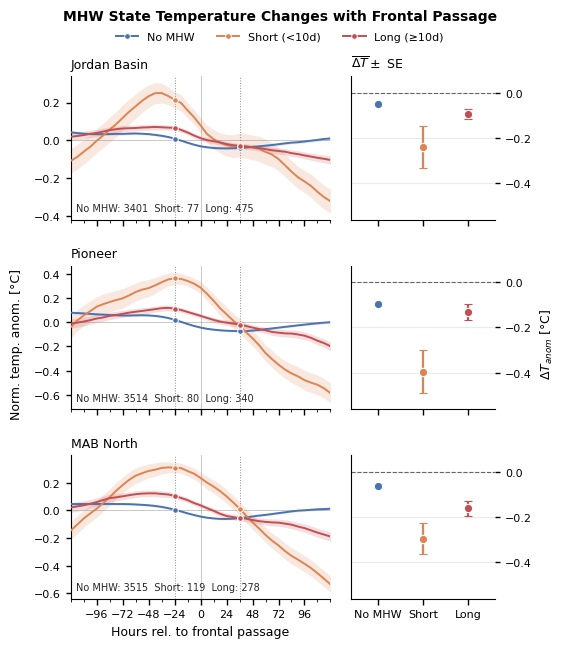

In [17]:
fig, axes = plot_composite_with_stderr(
    results=RESULTS,
    regions=REGIONS,
    lag_idx=(i_pre, i_post),
    var=VAR,
    band='se',             # 'se' | 'std' | None
    error_ylim='common',   # 'common' | 'per_row' | 'composite' | (lo, hi)
    plotsave=f'fig2_composite_stderr_{VAR}_dt_{DELTA_LAGS[0]}_{DELTA_LAGS[1]}hrs',
    # plotsave=f'fig2_composite_stderr_fstrength75th_percentile',

)
plt.show()


# SI Figures

In [18]:
def filter_front_by_months(front_metrics, months):
    result = {}
    for name, ds in front_metrics.items():
        times = np.array(ds['time_start'])
        month_vals = times.astype('datetime64[M]').astype(int) % 12 + 1
        mask = np.isin(month_vals, months)
        filtered = {}
        for key, val in ds.items():
            if isinstance(val, np.ndarray):
                filtered[key] = val[mask]
            elif isinstance(val, list):
                filtered[key] = [v for v, m in zip(val, mask) if m]
            else:
                filtered[key] = val
        result[name] = filtered
    return result


# standard seasons
front_metrics_DJF = filter_front_by_months(front_metrics_full, [12, 1, 2])
front_metrics_MAM = filter_front_by_months(front_metrics_full, [3, 4, 5])
front_metrics_JJA = filter_front_by_months(front_metrics_full, [6, 7 , 8])
front_metrics_SON = filter_front_by_months(front_metrics_full, [9, 10, 11])

# stratified vs unstratified (based on basend on bulk straitfication at Pioneer and Jordan Basin moorings)
front_metrics_destrat = filter_front_by_months(front_metrics_full, [12, 1, 2,3,4,5])
front_metrics_strat = filter_front_by_months(front_metrics_full, [6,7,8,9,10,11])

## Composites - strat vs unstrat

delta_t measured from -24 h to +36 h rel. to passage
 using VAR=tempa

JordanBasin    No MHW: 1973  Short: 30  Long: 216
Pioneer        No MHW: 2100  Short: 42  Long: 174
MAB_North      No MHW: 2105  Short: 46  Long: 139
Saving ../plots/manuscript/SI_composite_destratified_stderr_tempa_dt_-24_36hrs.jpg


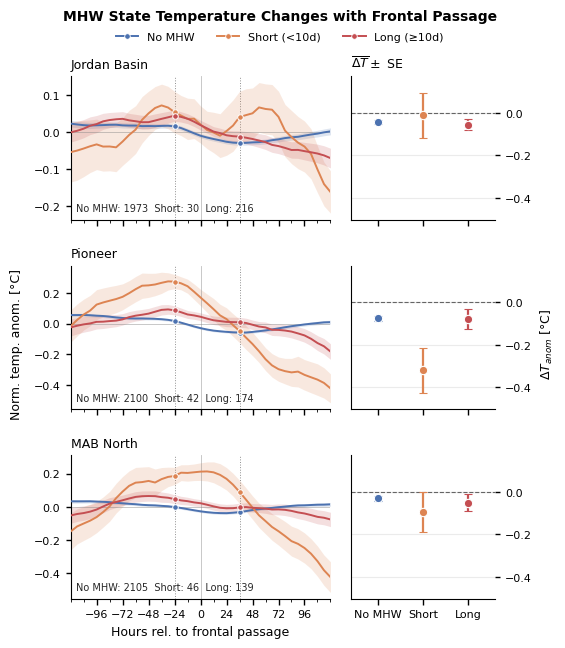

In [19]:
#----------------------------------------------------------
# unstratified (DJF,MAM)
#----------------------------------------------------------

# lag indices for delta_t
i_pre  = int(np.where(TIME == DELTA_LAGS[0])[0][0])
i_post = int(np.where(TIME == DELTA_LAGS[1])[0][0])
assert i_pre < i_post, f'DELTA_LAGS must be increasing, got {DELTA_LAGS}'
print(f'delta_t measured from {TIME[i_pre]:+d} h to {TIME[i_post]:+d} h rel. to passage\n using VAR={VAR}\n')

# build every region's groups, composites and delta_t stats
RESULTS = {}
DS = front_metrics_destrat

for name in REGIONS:
    temp_comp, wo_short, wo_no_mhw = extract_front_mhw_windows(
        name, DS[name], collocation=COLLOCATION,
        mhw_special='short', dx=DX_TIMESTEPS, var=VAR,
    )
    _, wo_long, _ = extract_front_mhw_windows(
        name, DS[name], collocation=COLLOCATION,
        mhw_special='long', dx=DX_TIMESTEPS, var=VAR,
    )

    masks = {'No MHW': wo_no_mhw, 'Short': wo_short, 'Long': wo_long}

    RESULTS[name] = {
        'curves': {s: composite_curve(temp_comp, masks[s], method=METHOD) for s in STATES},
        'points': {s: delta_t_stats(temp_comp, masks[s], i_pre, i_post) for s in STATES},
        'counts': {s: int(masks[s].sum()) for s in STATES},
    }

    counts = RESULTS[name]['counts']
    print(f'{name:14s} ' + '  '.join(f'{s}: {counts[s]}' for s in STATES))



fig, axes = plot_composite_with_stderr(
    results=RESULTS,
    regions=REGIONS,
    lag_idx=(i_pre, i_post),
    var=VAR,
    band='se',             # 'se' | 'std' | None
    error_ylim='common',   # 'common' | 'per_row' | 'composite' | (lo, hi)
    plotsave=f'SI_composite_destratified_stderr_{VAR}_dt_{DELTA_LAGS[0]}_{DELTA_LAGS[1]}hrs',
)
plt.show()

JordanBasin    No MHW: 1428  Short: 47  Long: 259
Pioneer        No MHW: 1414  Short: 38  Long: 166
MAB_North      No MHW: 1410  Short: 73  Long: 139
Saving ../plots/manuscript/SI_composite_stratified_stderr_tempa_dt_-24_36hrs.jpg


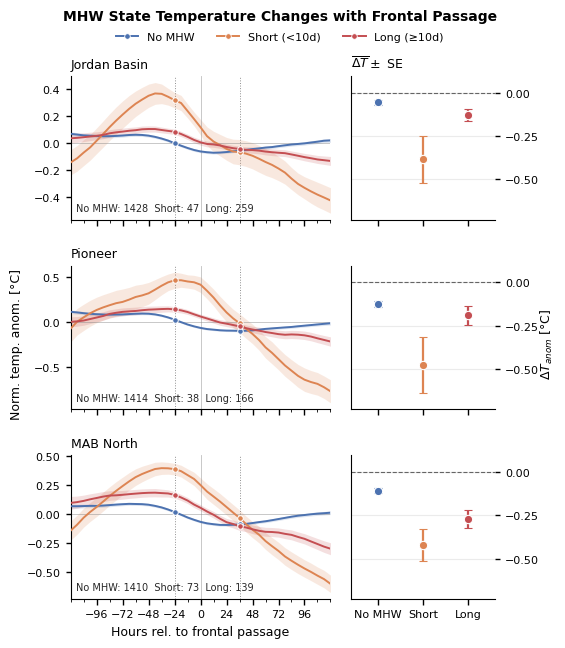

In [20]:
#----------------------------------------------------------
# stratified  (JJA, SON)
#----------------------------------------------------------

# build every region's groups, composites and delta_t stats
RESULTS = {}
DS = front_metrics_strat

for name in REGIONS:
    temp_comp, wo_short, wo_no_mhw = extract_front_mhw_windows(
        name, DS[name], collocation=COLLOCATION,
        mhw_special='short', dx=DX_TIMESTEPS, var=VAR,
    )
    _, wo_long, _ = extract_front_mhw_windows(
        name, DS[name], collocation=COLLOCATION,
        mhw_special='long', dx=DX_TIMESTEPS, var=VAR,
    )

    masks = {'No MHW': wo_no_mhw, 'Short': wo_short, 'Long': wo_long}

    RESULTS[name] = {
        'curves': {s: composite_curve(temp_comp, masks[s], method=METHOD) for s in STATES},
        'points': {s: delta_t_stats(temp_comp, masks[s], i_pre, i_post) for s in STATES},
        'counts': {s: int(masks[s].sum()) for s in STATES},
    }

    counts = RESULTS[name]['counts']
    print(f'{name:14s} ' + '  '.join(f'{s}: {counts[s]}' for s in STATES))





fig, axes = plot_composite_with_stderr(
    results=RESULTS,
    regions=REGIONS,
    lag_idx=(i_pre, i_post),
    var=VAR,
    band='se',             # 'se' | 'std' | None
    error_ylim='common',   # 'common' | 'per_row' | 'composite' | (lo, hi)
    plotsave=f'SI_composite_stratified_stderr_{VAR}_dt_{DELTA_LAGS[0]}_{DELTA_LAGS[1]}hrs',
)
plt.show()

## Full compsite different time interval

delta_t measured from -96 h to +96 h rel. to passage
 using VAR=tempa

JordanBasin    No MHW: 3401  Short: 77  Long: 475
Pioneer        No MHW: 3514  Short: 80  Long: 340
MAB_North      No MHW: 3515  Short: 119  Long: 278
Saving ../plots/manuscript/fig2_composite_stderr_tempa_dt_-96_96hrs.jpg


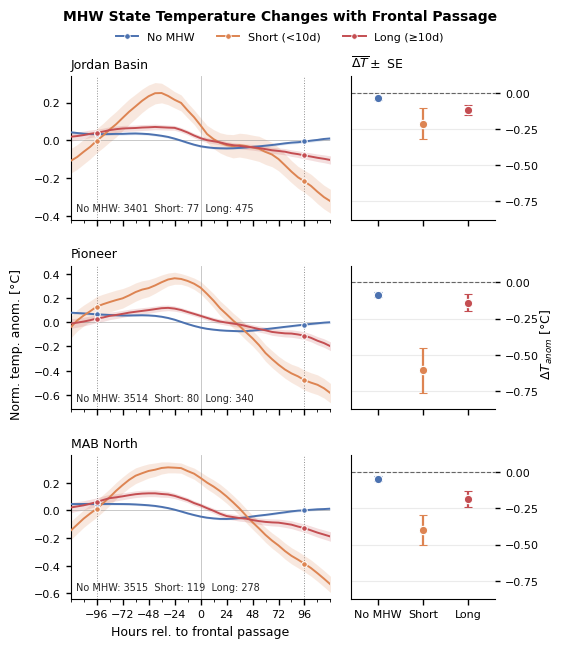

In [21]:
#------------------------------------------------------------------
# full composite for -96 to +96 hours
#------------------------------------------------------------------
DELTA_LAGS = [-96, 96]


# lag indices for delta_t
i_pre  = int(np.where(TIME == DELTA_LAGS[0])[0][0])
i_post = int(np.where(TIME == DELTA_LAGS[1])[0][0])
assert i_pre < i_post, f'DELTA_LAGS must be increasing, got {DELTA_LAGS}'
print(f'delta_t measured from {TIME[i_pre]:+d} h to {TIME[i_post]:+d} h rel. to passage\n using VAR={VAR}\n')

# build every region's groups, composites and delta_t stats
RESULTS = {}

for name in REGIONS:
    temp_comp, wo_short, wo_no_mhw = extract_front_mhw_windows(
        name, front_metrics_full[name], collocation=COLLOCATION,
        mhw_special='short', dx=DX_TIMESTEPS, var=VAR,
    )
    _, wo_long, _ = extract_front_mhw_windows(
        name, front_metrics_full[name], collocation=COLLOCATION,
        mhw_special='long', dx=DX_TIMESTEPS, var=VAR,
    )

    masks = {'No MHW': wo_no_mhw, 'Short': wo_short, 'Long': wo_long}

    RESULTS[name] = {
        'curves': {s: composite_curve(temp_comp, masks[s], method=METHOD) for s in STATES},
        'points': {s: delta_t_stats(temp_comp, masks[s], i_pre, i_post) for s in STATES},
        'counts': {s: int(masks[s].sum()) for s in STATES},
    }

    counts = RESULTS[name]['counts']
    print(f'{name:14s} ' + '  '.join(f'{s}: {counts[s]}' for s in STATES))





fig, axes = plot_composite_with_stderr(
    results=RESULTS,
    regions=REGIONS,
    lag_idx=(i_pre, i_post),
    var=VAR,
    band='se',             # 'se' | 'std' | None
    error_ylim='common',   # 'common' | 'per_row' | 'composite' | (lo, hi)
    plotsave=f'fig2_composite_stderr_{VAR}_dt_{DELTA_LAGS[0]}_{DELTA_LAGS[1]}hrs',
    # plotsave=f'fig2_composite_stderr_fstrength75th_percentile',

)
plt.show()
